In [17]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [18]:
airports = pd.read_csv(
    "../../data/processed/airports/airports_feature_engineered.csv"
)

countries = pd.read_csv(
    "../../data/processed/airports/countries/countries_processed.csv"
)

regions = pd.read_csv(
    "../../data/processed/airports/regions/regions_processed.csv"
)

runways = pd.read_csv(
    "../../data/processed/airports/airport_runway_summary.csv"
)

In [19]:
airports.columns

Index(['id', 'ident', 'type', 'name', 'latitude_deg', 'longitude_deg',
       'elevation_ft', 'continent', 'iso_country', 'iso_region',
       'municipality', 'scheduled_service', 'icao_code', 'iata_code',
       'gps_code', 'airport_size', 'airport_category', 'commercial_airport',
       'elevation_category', 'hemisphere', 'climate_zone',
       'airport_importance'],
      dtype='object')

In [20]:
print("="*50)
print("INPUT DATASET SHAPES")
print("="*50)

print("Airports :", airports.shape)
print("Countries :", countries.shape)
print("Regions :", regions.shape)
print("Runways :", runways.shape)

INPUT DATASET SHAPES
Airports : (85670, 22)
Countries : (249, 4)
Regions : (3982, 6)
Runways : (40979, 9)


In [21]:
airport_master = airports.merge(
    countries[
        [
            "code",
            "name",
            "continent"
        ]
    ],
    how="left",
    left_on="iso_country",
    right_on="code"
)

In [22]:
airport_master.rename(
    columns={
        "name_y": "country_name",
        "continent_y": "country_continent"
    },
    inplace=True
)

In [23]:
airport_master.drop(
    columns=["code"],
    inplace=True
)

In [24]:
airport_master = airport_master.merge(
    regions[
        [
            "code",
            "name"
        ]
    ],
    how="left",
    left_on="iso_region",
    right_on="code"
)

In [25]:
airport_master.rename(
    columns={
        "name": "region_name"
    },
    inplace=True
)

In [26]:
airport_master.drop(
    columns=["code"],
    inplace=True
)

In [27]:
airport_master = airport_master.merge(
    runways,
    how="left",
    left_on="ident",
    right_on="airport_ident"
)

In [28]:
airport_master.drop(
    columns=["airport_ident"],
    inplace=True
)

In [31]:
airport_master.drop(
    columns=["continent_x"],
    inplace=True
)

In [32]:
airport_master.rename(
    columns={
        "name_x": "airport_name"
    },
    inplace=True
)

In [33]:
airport_master.columns

Index(['id', 'ident', 'type', 'airport_name', 'latitude_deg', 'longitude_deg',
       'elevation_ft', 'iso_country', 'iso_region', 'municipality',
       'scheduled_service', 'icao_code', 'iata_code', 'gps_code',
       'airport_size', 'airport_category', 'commercial_airport',
       'elevation_category', 'hemisphere', 'climate_zone',
       'airport_importance', 'country_name', 'country_continent',
       'region_name', 'runway_count', 'longest_runway_ft',
       'average_runway_length_ft', 'average_runway_width_ft',
       'lighted_runways', 'closed_runways', 'dominant_surface',
       'maximum_runway_capability'],
      dtype='object')

In [34]:
print("Airport Master Shape:", airport_master.shape)

print("Duplicate Airports:",
      airport_master["ident"].duplicated().sum())

print("Missing Country Names:",
      airport_master["country_name"].isnull().sum())

print("Missing Region Names:",
      airport_master["region_name"].isnull().sum())

print("Airports with Runway Information:",
      airport_master["runway_count"].notna().sum())

Airport Master Shape: (85670, 32)
Duplicate Airports: 0
Missing Country Names: 303
Missing Region Names: 0
Airports with Runway Information: 40979


In [35]:
airport_master = airport_master[[
    "id",
    "ident",
    "airport_name",
    "type",
    "airport_size",
    "airport_category",
    "airport_importance",
    "commercial_airport",
    "municipality",
    "iso_country",
    "country_name",
    "country_continent",
    "iso_region",
    "region_name",
    "latitude_deg",
    "longitude_deg",
    "elevation_ft",
    "elevation_category",
    "hemisphere",
    "climate_zone",
    "scheduled_service",
    "icao_code",
    "iata_code",
    "gps_code",
    "runway_count",
    "longest_runway_ft",
    "average_runway_length_ft",
    "average_runway_width_ft",
    "lighted_runways",
    "closed_runways",
    "dominant_surface",
    "maximum_runway_capability"
]]

In [36]:
print("Airport Master Shape:", airport_master.shape)

Airport Master Shape: (85670, 32)


In [37]:
missing = pd.DataFrame({
    "Missing Values": airport_master.isnull().sum(),
    "Percentage": (
        airport_master.isnull().mean() * 100
    ).round(2)
})

missing.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
iata_code,76614,89.43
icao_code,75451,88.07
runway_count,44691,52.17
longest_runway_ft,44691,52.17
lighted_runways,44691,52.17
closed_runways,44691,52.17
average_runway_length_ft,44691,52.17
average_runway_width_ft,44691,52.17
maximum_runway_capability,44691,52.17
dominant_surface,44691,52.17


In [38]:
print(
    "Duplicate Airports:",
    airport_master["ident"].duplicated().sum()
)

Duplicate Airports: 0


In [39]:
print("Total Airports:", airport_master.shape[0])

print(
    "Airports with Runway Information:",
    airport_master["runway_count"].notna().sum()
)

print(
    "Airports without Runway Information:",
    airport_master["runway_count"].isna().sum()
)

Total Airports: 85670
Airports with Runway Information: 40979
Airports without Runway Information: 44691


In [40]:
airport_master[
    [
        "runway_count",
        "longest_runway_ft",
        "average_runway_length_ft",
        "average_runway_width_ft"
    ]
].describe()

,runway_count,longest_runway_ft,average_runway_length_ft,average_runway_width_ft
count,40979.000000,40979.000000,40979.000000,40979.000000
mean,1.173137,3128.024378,3005.123500,99.698958
std,0.507703,2694.131416,2543.019384,201.957730
min,1.000000,0.000000,0.000000,-1.000000
25%,1.000000,1500.000000,1476.000000,59.000000
50%,1.000000,2625.000000,2625.000000,75.000000
75%,1.000000,4003.000000,3937.000000,100.000000
max,11.000000,30000.000000,30000.000000,9000.000000


In [41]:
airport_master.head()

,id,ident,airport_name,type,airport_size,airport_category,airport_importance,commercial_airport,municipality,iso_country,country_name,country_continent,iso_region,region_name,latitude_deg,longitude_deg,elevation_ft,elevation_category,hemisphere,climate_zone,scheduled_service,icao_code,iata_code,gps_code,runway_count,longest_runway_ft,average_runway_length_ft,average_runway_width_ft,lighted_runways,closed_runways,dominant_surface,maximum_runway_capability
0,6523,00A,Total RF Heliport,heliport,Heliport,Heliport,Low,0,Bensalem,US,United States,NaN,US-PA,Pennsylvania,40.070985,-74.933689,11.0,Low,Northern,Temperate,no,NaN,NaN,K00A,1.0,80.0,80.0,80.0,1.0,0.0,ASPHALT,Basic
1,323361,00AA,Aero B Ranch Airport,small_airport,Small,Local,Low,0,Leoti,US,United States,NaN,US-KS,Kansas,38.704022,-101.473911,3435.0,Medium,Northern,Subtropical,no,NaN,NaN,00AA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6524,00AK,Lowell Field,small_airport,Small,Local,Low,0,Anchor Point,US,United States,NaN,US-AK,Alaska,59.947733,-151.692524,450.0,Low,Northern,Temperate,no,NaN,NaN,00AK,1.0,2500.0,2500.0,40.0,0.0,0.0,GRAVEL,Basic
3,6525,00AL,Epps Airpark,small_airport,Small,Local,Low,0,Harvest,US,United States,NaN,US-AL,Alabama,34.864799,-86.770302,820.0,Low,Northern,Subtropical,no,NaN,NaN,00AL,1.0,2100.0,2100.0,90.0,0.0,0.0,GRASS/TURF,Basic
4,506791,00AN,Katmai Lodge Airport,small_airport,Small,Local,Low,0,King Salmon,US,United States,NaN,US-AK,Alaska,59.093287,-156.456699,80.0,Low,Northern,Temperate,no,NaN,NaN,00AN,1.0,4517.0,4517.0,60.0,0.0,0.0,OTHER,Basic


In [42]:
airport_master.sample(10)

,id,ident,airport_name,type,airport_size,airport_category,airport_importance,commercial_airport,municipality,iso_country,country_name,country_continent,iso_region,region_name,latitude_deg,longitude_deg,elevation_ft,elevation_category,hemisphere,climate_zone,scheduled_service,icao_code,iata_code,gps_code,runway_count,longest_runway_ft,average_runway_length_ft,average_runway_width_ft,lighted_runways,closed_runways,dominant_surface,maximum_runway_capability
45714,42063,MHFN,San Fernando Airport,small_airport,Small,Local,Low,0,San Fernando,HN,Honduras,NaN,HN-FM,Francisco Morazán Department,14.113333,-86.952782,648.0,Low,Northern,Tropical,no,NaN,NaN,MHFN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9622,351605,AE-0097,Barakah Nuclear Power Plant Heliport,heliport,Heliport,Heliport,Low,0,Barakah,AE,United Arab Emirates,AS,AE-AZ,Abu Dhabi Emirate,23.963450,52.244150,20.0,Low,Northern,Subtropical,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35939,343885,JP-1913,Senri Chuo River Garden South Helipad,heliport,Heliport,Heliport,Low,0,Toyonaka,JP,Japan,AS,JP-27,Ōsaka Prefecture,34.804770,135.491350,728.0,Low,Northern,Subtropical,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83973,27793,YMNY,Morney Airport,small_airport,Small,Local,Low,0,Unknown,AU,Australia,OC,AU-QLD,Queensland,-25.358299,141.432999,104.0,Low,Southern,Subtropical,no,YMNY,OXY,YMNY,1.0,3608.0,3608.0,75.0,0.0,0.0,OTHER,Basic
21088,1729,CYFB,Iqaluit Airport,medium_airport,Medium,Regional,Medium,1,Iqaluit,CA,Canada,NaN,CA-NU,Nunavut,63.756402,-68.555801,110.0,Low,Northern,Polar,yes,CYFB,YFB,CYFB,1.0,8605.0,8605.0,200.0,1.0,0.0,ASPHALT,High
29888,29110,GB-1229,Long Marston Airfield,closed,Closed,Other,Low,0,"Long Marston, Warwickshire",GB,United Kingdom,EU,GB-ENG,England,52.140301,-1.753610,154.0,Low,Northern,Temperate,no,NaN,NaN,NaN,2.0,1805.0,1780.0,75.0,0.0,0.0,UNKNOWN,Basic
5822,12395,5II9,Aero Plaines Airport,small_airport,Small,Local,Low,0,Youngstown,US,United States,NaN,US-IN,Indiana,39.352798,-87.373398,570.0,Low,Northern,Subtropical,no,NaN,NaN,5II9,1.0,2450.0,2450.0,200.0,0.0,0.0,GRASS/TURF,Basic
76675,354063,US-6801,Ney Cave Airport,closed,Closed,Other,Low,0,Hondo,US,United States,NaN,US-TX,Texas,29.613157,-99.125108,1353.0,Medium,Northern,Subtropical,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9870,32238,AGGU,Marau Airport,small_airport,Small,Local,Low,1,Marau,SB,Solomon Islands,OC,SB-GU,Guadalcanal Province,-9.861670,160.824997,3.0,Low,Southern,Tropical,yes,AGGU,RUS,AGGU,1.0,2001.0,2001.0,98.0,0.0,0.0,OTHER,Basic
22899,32095,DIOF,Ouango Fitini Airport,small_airport,Small,Local,Low,0,Ouango Fitini,CI,Côte d'Ivoire,AF,CI-ZZ,Zanzan District,9.600000,-4.050000,974.0,Low,Northern,Tropical,no,DIOF,OFI,DIOF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
airport_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85670 entries, 0 to 85669
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         85670 non-null  int64  
 1   ident                      85670 non-null  object 
 2   airport_name               85670 non-null  object 
 3   type                       85670 non-null  object 
 4   airport_size               85670 non-null  object 
 5   airport_category           85670 non-null  object 
 6   airport_importance         85670 non-null  object 
 7   commercial_airport         85670 non-null  int64  
 8   municipality               85670 non-null  object 
 9   iso_country                85670 non-null  object 
 10  country_name               85367 non-null  object 
 11  country_continent          45600 non-null  object 
 12  iso_region                 85670 non-null  object 
 13  region_name                85670 non-null  obj

In [45]:
print("="*60)
print("AIRPORT MASTER DATASET SUMMARY")
print("="*60)

print(f"Rows: {airport_master.shape[0]}")
print(f"Columns: {airport_master.shape[1]}")
print(f"Unique Airports: {airport_master['ident'].nunique()}")
print(f"Duplicate Airports: {airport_master['ident'].duplicated().sum()}")

print(f"\nRunway Coverage: {airport_master['runway_count'].notna().sum()} airports")

print(f"Countries Represented: {airport_master['iso_country'].nunique()}")

print(f"Regions Represented: {airport_master['iso_region'].nunique()}")

AIRPORT MASTER DATASET SUMMARY
Rows: 85670
Columns: 32
Unique Airports: 85670
Duplicate Airports: 0

Runway Coverage: 40979 airports
Countries Represented: 247
Regions Represented: 3007


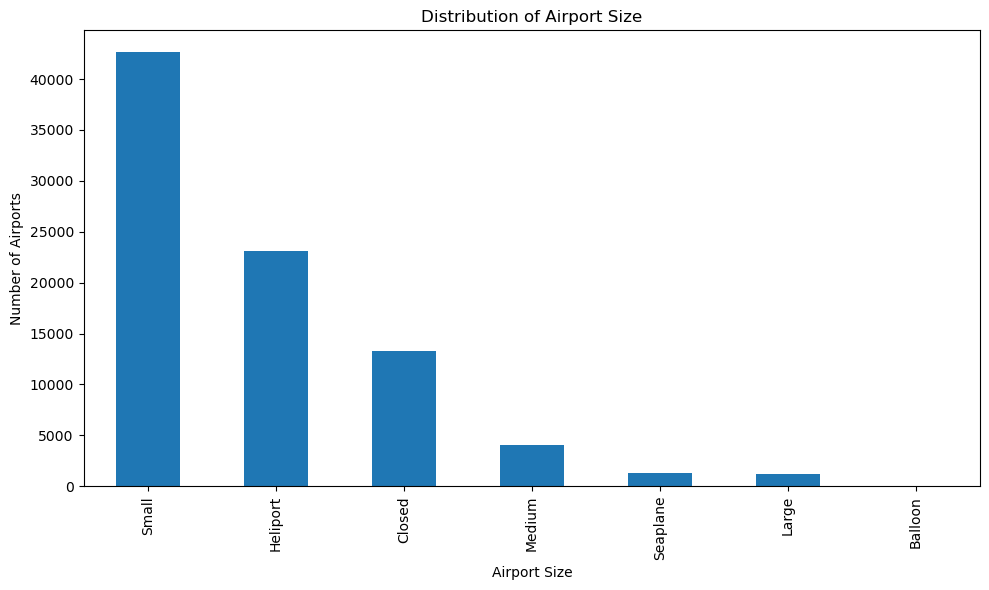

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

airport_master["airport_size"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Airport Size")
plt.xlabel("Airport Size")
plt.ylabel("Number of Airports")

plt.tight_layout()
plt.show()

In [47]:
airport_master.to_csv(
    "../../data/processed/airports/airport_master.csv",
    index=False
)

print("Airport Master Dataset saved successfully.")

Airport Master Dataset saved successfully.


## Airport Module Integration Summary

The airport, country, region, and runway datasets were successfully integrated to create the Airport Master Dataset. Country and region information were merged using standardized ISO country and region codes, while aggregated runway infrastructure metrics were merged using the airport identifier. The resulting dataset provides a unified airport-level representation that combines airport characteristics, geographic information, and runway operational capability. This Airport Master Dataset serves as the primary airport reference dataset for subsequent integration with flight operations, weather, aircraft metadata, and delay datasets in the proposed Flight Operations Analytics and Decision Support Dashboard.